# Introduction
As a international Student managing expenses and tracking them is very diffcult as we have bills to pay and money to safe. Even though we make a goal to save some we will have tought time when we deal with unplanned circumstances. Here I have used my personal expenses which i have tracked using excel sheet. In this Notebook I have cleaned the data and analysed my spending habits and extracted insights from the plots 

In [40]:
import pandas as pd
import numpy as np

## Data Loading

In [42]:
df = pd.read_excel('Personal Finance.xlsx',sheet_name ='January')
df.head(10)

,OUTFLOW EVERYMONTH,EXPENSES,INCOME,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,425,RENT,7231.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,42.15,WIFI & RECHARGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,ELECTRICITY BILL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,152,OPAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,127,GROCIERS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0,WOOLIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,107,SWIMMING,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,25,beer and pizza,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,50,withdraw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,56,food,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cleaning the data

In [140]:
df = pd.read_excel('Personal Finance.xlsx',sheet_name =None)
month = ['Novemeber ','December ','January','feb','March','april']
all_months =[]
for sheet_name,df1 in df.items():
    if sheet_name in month:
        df_month =df1
        df_month =df1 [['OUTFLOW EVERYMONTH','EXPENSES ']]
        df_month =df_month.rename(columns ={'OUTFLOW EVERYMONTH' :'Amount',"EXPENSES " : 'Category'})
        df_month['Amount'] = pd.to_numeric(df_month['Amount'], errors ='coerce')
        df_month = df_month.dropna()
        df_month = df_month[~df_month['Category'].isin(["TOTAL","MANDATORY ","UNWANTED "])]
        df_month["months"] = sheet_name
        all_months.append(df_month)
        
combined_months = pd.concat(all_months,ignore_index = True)
print(combined_months)
    
    

    Amount                 Category      months
0   425.00                     RENT  Novemeber 
1    62.05          WIFI & RECHARGE  Novemeber 
2   185.50        ELECTRICITY BILL   Novemeber 
3   162.00                     OPAL  Novemeber 
4   108.35                     BEER  Novemeber 
5    85.34                 GROCIERS  Novemeber 
6    46.24                  WOOLIES  Novemeber 
7   140.12                 SWIMMING  Novemeber 
8   116.01  HEALTHCARE VACCINATION   Novemeber 
9    86.49                     FOOD  Novemeber 
10  425.00                     RENT   December 
11   42.15                    WIFI    December 
12   44.90                 recharge   December 
13  174.36                     OPAL   December 
14  105.10                     BEER   December 
15   14.85                 GROCIERS   December 
16   28.85                  WOOLIES   December 
17  160.68                 SWIMMING   December 
18  102.09               FOOD/movie   December 
19  104.00                     trip   De

## Analysis

In [158]:
combined_months['months'] = combined_months['months'].replace({'Novemeber ': 'Nov 25',
                                   'December ': 'Dec 25','January': 'Jan 26','March': 'Mar 26',
                                  'april': 'Apr 26','feb': 'Feb 26'})
combined_months['months'] =pd.Categorical(combined_months['months'], categories = ['Nov 25','Dec 25','Jan 26','Feb 26','Mar 26','Apr 26'], ordered =True)
print(combined_months)

    Amount                 Category  months
0   425.00                     RENT  Nov 25
1    62.05          WIFI & RECHARGE  Nov 25
2   185.50        ELECTRICITY BILL   Nov 25
3   162.00                     OPAL  Nov 25
4   108.35                     BEER  Nov 25
5    85.34                 GROCIERS  Nov 25
6    46.24                  WOOLIES  Nov 25
7   140.12                 SWIMMING  Nov 25
8   116.01  HEALTHCARE VACCINATION   Nov 25
9    86.49                     FOOD  Nov 25
10  425.00                     RENT  Dec 25
11   42.15                    WIFI   Dec 25
12   44.90                 recharge  Dec 25
13  174.36                     OPAL  Dec 25
14  105.10                     BEER  Dec 25
15   14.85                 GROCIERS  Dec 25
16   28.85                  WOOLIES  Dec 25
17  160.68                 SWIMMING  Dec 25
18  102.09               FOOD/movie  Dec 25
19  104.00                     trip  Dec 25
20  425.00                     RENT  Jan 26
21   42.15          WIFI & RECHA

In [160]:
sum_months = combined_months.groupby('months') ['Amount'].sum()
sum_months.head(10)

months
Nov 25    1417.10
Dec 25    1201.98
Jan 26     984.15
Feb 26     974.96
Mar 26    1379.46
Apr 26    1111.14
Name: Amount, dtype: float64

## Plotting 

Text(0, 0.5, 'Amount(AUD)')

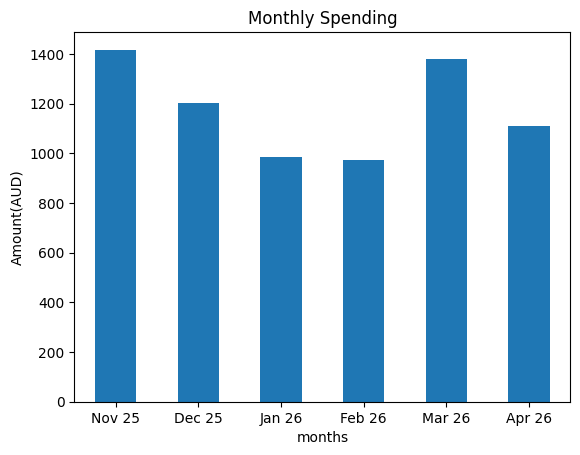

In [163]:
cus = ['Nov 25','Dec 25','Jan 26','Feb 26','Mar 26','Apr 26']
ax= sum_months.plot.bar(rot =0)
ax.set_title('Monthly Spending')
ax.set_xlabel('months')
ax.set_ylabel('Amount(AUD)')

In [165]:
sum_category = combined_months.groupby('Category') ['Amount'].sum()
sum_category.head(30)
print(type(sum_category))

<class 'pandas.Series'>


In [167]:
sort_category = sum_category.sort_values(ascending=False)
top_10 = sort_category.head(10)

Text(0, 0.5, 'Amount(AUD)')

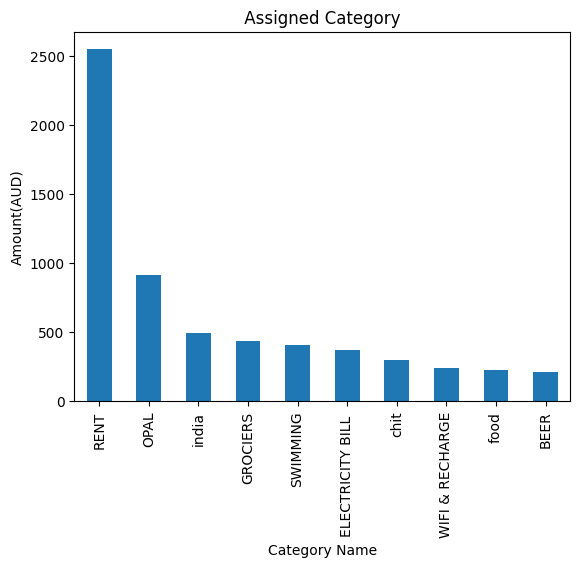

In [169]:

axe = top_10.plot.bar(rot=90)
axe.set_title(" Assigned Category ")
axe.set_xlabel("Category Name")
axe.set_ylabel("Amount(AUD)")

## Insights 

1) Rent accounts for $2,550 out of total spending — approximately 35% of all expenses. This is a fixed cost that cannot be reduced, so opportunities for savings lie in discretionary categories like transport and food.
2) November accounts for 1417 AUD, 45% in increase in expenditure when compared with February, which has the least expenditure with 974 AUD
3) We can see a trend in the spending curve where it peaked in November and eventually decreased, and a sharp rise in March
4) Opal card, which is used for travel , wifi, and electricity, cannot be compromised as it is a mandatory requirement but savings can be increased by reducing on groceries and the food section, as we have the option to be flexible to purchase discount products
5) From monthly spending, we can say that a minimum of 975 AUD is required for a lifestyle in Australia 